# Step E — `01_explore_yambda`: интеграционный тест `src/data/*` + графики для ВКР

Этот ноутбук **не дублирует** EDA-числа из `00_data_discovery.ipynb`. У него две задачи:

1. **Интеграционный тест** — проверить, что `src.data.yambda_loader` и `src.data.splits` дают те же числа, что были зафиксированы в Step 0 (после применения `filter_min_popularity≥5`, который в Step 0 ещё не применялся).
2. **Графики для текста ВКР** — сохранить 3 figure'а в `docs/figures/`:
    - распределение длин историй (post-filter, log-y);
    - item popularity (Zipf, log-log) — до и после `min_pop≥5`;
    - timeline `train / val / test` по timestamp с границами GTS.

**Окружение:** локально на M4 Pro (HF-кэш горячий после Step 0).

## 1. Setup

In [1]:
import os, sys, gc
from pathlib import Path

# Add project root to sys.path so `import src.data.*` works from notebooks/
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

FIG_DIR = PROJECT_ROOT / 'docs' / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)
print('PROJECT_ROOT:', PROJECT_ROOT)
print('FIG_DIR     :', FIG_DIR)

PROJECT_ROOT: /Users/vladpalamarchuk/Documents/Учеба/HSE/thesis/music-recommendations
FIG_DIR     : /Users/vladpalamarchuk/Documents/Учеба/HSE/thesis/music-recommendations/docs/figures


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data.yambda_loader import (
    load_yambda,
    filter_listens,
    filter_min_popularity,
    build_item_id_to_idx,
    apply_item_remap,
)
from src.data.splits import (
    global_temporal_split,
    SplitConfig,
    TEST_TIMESTAMP,
    VAL_SIZE,
    GAP_SIZE,
)
from src.utils.seed import set_seed

set_seed(42, deterministic_torch=False)  # torch не используется в этом ноутбуке

plt.rcParams.update({
    'figure.dpi': 110,
    'savefig.dpi': 200,
    'figure.figsize': (8, 4),
    'axes.grid': True,
    'grid.alpha': 0.3,
})

## 2. Load + filter pipeline (через `src.data.yambda_loader`)

Канонический порядок (зафиксирован в `phase_1_log.md`, сессия Step C-D):

```
load_yambda → filter_listens → filter_min_popularity(≥5) → build_item_id_to_idx → apply_item_remap → global_temporal_split
```

На каждом шаге печатаем размеры — **этот вывод служит чекпоинтом**: если loader даст другие числа, чем Step 0 / Step C-D real-data validation, увидим сразу.

In [3]:
data = load_yambda('50m')
raw = data['interactions']
print(f'load_yambda             : {len(raw):>12,} events, {raw["uid"].nunique():>6,} users')

load_yambda             :   47,790,449 events, 10,000 users


In [4]:
listens_full = filter_listens(raw, threshold_pct=50)
n_items_pre  = listens_full['item_id'].nunique()
print(f'filter_listens(>=50%)   : {len(listens_full):>12,} events, '
      f'{listens_full["uid"].nunique():>6,} users, {n_items_pre:>7,} items')

# Sanity vs Step 0
assert len(listens_full) == 29_439_278, len(listens_full)
assert listens_full['uid'].nunique() == 9_209
assert n_items_pre == 631_003
print('OK — совпадает со Step 0')

filter_listens(>=50%)   :   29,439,278 events,  9,209 users, 631,003 items
OK — совпадает со Step 0


In [5]:
listens = filter_min_popularity(listens_full, min_count=5)
n_items_post = listens['item_id'].nunique()
print(f'filter_min_popularity≥5 : {len(listens):>12,} events, '
      f'{listens["uid"].nunique():>6,} users, {n_items_post:>7,} items')
print(f'  items dropped         : {n_items_pre - n_items_post:>7,} '
      f'({(n_items_pre - n_items_post)/n_items_pre*100:.1f}%)')
print(f'  events dropped        : {len(listens_full) - len(listens):>12,} '
      f'({(len(listens_full) - len(listens))/len(listens_full)*100:.2f}%)')

filter_min_popularity≥5 :   28,819,720 events,  9,195 users, 276,305 items
  items dropped         : 354,698 (56.2%)
  events dropped        :      619,558 (2.10%)


In [6]:
item_id_to_idx = build_item_id_to_idx(listens)
listens = apply_item_remap(listens, item_id_to_idx)
print(f'item_idx range          : [{listens["item_idx"].min()}, {listens["item_idx"].max()}]  '
      f'(0 reserved for padding)')
assert listens['item_idx'].min() == 1
assert listens['item_idx'].max() == n_items_post

item_idx range          : [1, 276305]  (0 reserved for padding)


## 3. GTS split (через `src.data.splits`)

Параметры — yambda Constants по умолчанию: `test_timestamp=25_913_600`, `val_size=86_400`, `gap=1_800`.

In [8]:
train, val, test = global_temporal_split(listens, SplitConfig())

def desc(name, df):
    print(f'{name:>5}: {len(df):>12,} events  '
          f'{df["uid"].nunique():>6,} users  '
          f'ts ∈ [{df["timestamp"].min():>9,}, {df["timestamp"].max():>9,}]')

desc('train', train); desc('val', val); desc('test', test)

# Инварианты
train_uids = set(train['uid'].unique())
assert set(val['uid'].unique()).issubset(train_uids), 'val.uid ⊄ train.uid'
assert set(test['uid'].unique()).issubset(train_uids), 'test.uid ⊄ train.uid'
assert train['timestamp'].max() < val['timestamp'].min()  # gap соблюдён
assert val['timestamp'].max() < test['timestamp'].min()
print('\nOK — инварианты GTS держатся (val⊆train, test⊆train, дизъюнктность по времени)')

train:   28,524,373 events   9,194 users  ts ∈ [        0, 25,823,595]
  val:      139,455 events   4,596 users  ts ∈ [25,825,400, 25,911,795]
 test:      153,140 events   4,576 users  ts ∈ [25,913,600, 25,999,995]

OK — инварианты GTS держатся (val⊆train, test⊆train, дизъюнктность по времени)


## 4. Графики для ВКР

Сохраняем в `docs/figures/` как PNG (200dpi). Для LaTeX потом — конвертируем в PDF через `inkscape` или просто включаем PNG.

### 4.1. Распределение длин историй (post-filter, post-min_pop)

Объясняет выбор `max_seq_len=200`: где медиана 1798, при урезании до 200 покрываем top-200 свежих по времени треков (≈11% медианной истории, но в SASRec это стандарт).

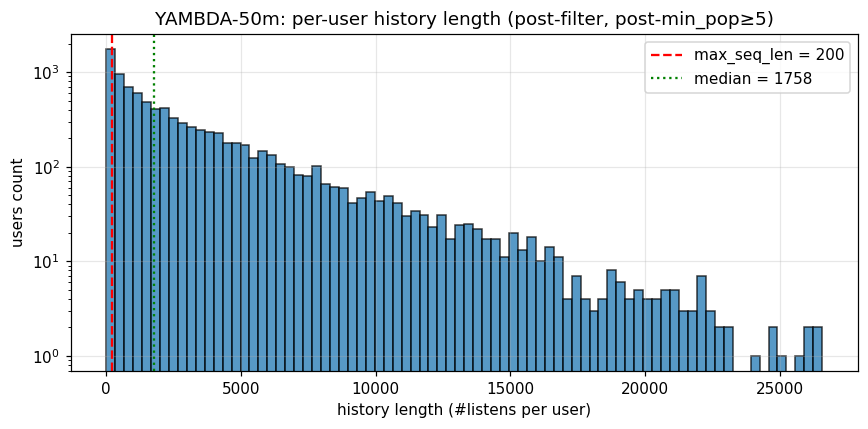

median=1758, 95p=10961, 99p=16889, max=26574


In [9]:
user_hist = listens.groupby('uid', sort=False).size()

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(user_hist.values, bins=80, edgecolor='black', alpha=0.75)
ax.axvline(200,  color='red',    linestyle='--', label='max_seq_len = 200')
ax.axvline(user_hist.median(), color='green', linestyle=':', label=f'median = {user_hist.median():.0f}')
ax.set_xlabel('history length (#listens per user)')
ax.set_ylabel('users count')
ax.set_yscale('log')
ax.set_title('YAMBDA-50m: per-user history length (post-filter, post-min_pop≥5)')
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / 'history_length_hist.png', bbox_inches='tight')
plt.show()

print(f'median={user_hist.median():.0f}, 95p={user_hist.quantile(0.95):.0f}, '
      f'99p={user_hist.quantile(0.99):.0f}, max={user_hist.max():.0f}')

### 4.2. Item popularity (Zipf, log-log) — до и после `min_pop≥5`

Объясняет, почему отбрасываем хвост: 56% items имеют <5 прослушиваний — для них embedding не успеет научиться, они только увеличивают таблицу.

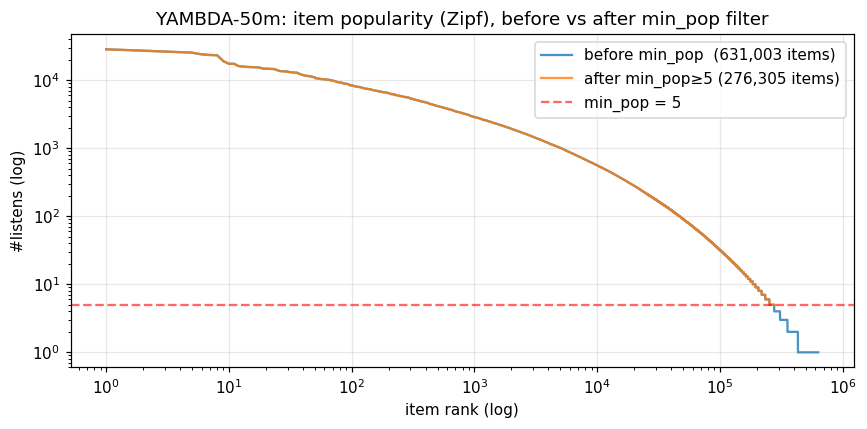

pre : top-1 has 28,268 listens; tail (rank 100k+): 32 listens
post: top-1 has 28,268 listens; tail (rank 100k+): 32 listens


In [10]:
pop_pre  = listens_full['item_id'].value_counts().sort_values(ascending=False).values
pop_post = listens['item_id'].value_counts().sort_values(ascending=False).values

fig, ax = plt.subplots(figsize=(8, 4))
ax.loglog(np.arange(1, len(pop_pre) + 1),  pop_pre,  label=f'before min_pop  ({len(pop_pre):,} items)', alpha=0.8)
ax.loglog(np.arange(1, len(pop_post) + 1), pop_post, label=f'after min_pop≥5 ({len(pop_post):,} items)', alpha=0.8)
ax.axhline(5, color='red', linestyle='--', alpha=0.6, label='min_pop = 5')
ax.set_xlabel('item rank (log)')
ax.set_ylabel('#listens (log)')
ax.set_title('YAMBDA-50m: item popularity (Zipf), before vs after min_pop filter')
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / 'item_popularity_zipf.png', bbox_inches='tight')
plt.show()

print(f'pre : top-1 has {pop_pre[0]:,} listens; tail (rank 100k+): {pop_pre[100_000]} listens')
print(f'post: top-1 has {pop_post[0]:,} listens; tail (rank 100k+): {pop_post[100_000]} listens')

### 4.3. Timeline `train / val / test` по timestamp

Показывает, насколько мала валидационная и тестовая полоса (по 1 дню) на фоне ~300-дневной обучающей выборки. Помогает обосновать выбор GTS-параметров в тексте.

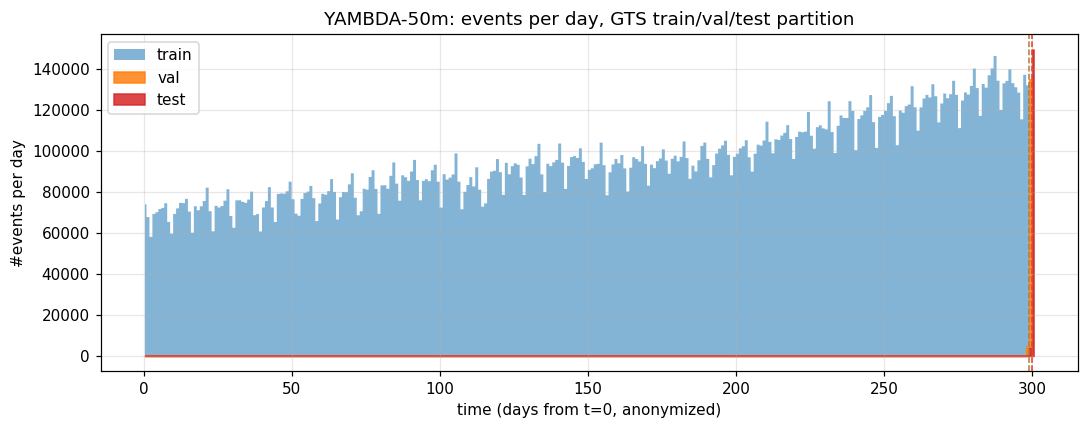

In [11]:
# Bin events into 1-day buckets (86_400 sec/day)
BIN = 86_400
ts_min, ts_max = listens['timestamp'].min(), listens['timestamp'].max()
edges = np.arange(ts_min, ts_max + BIN, BIN)

h_train, _ = np.histogram(train['timestamp'], bins=edges)
h_val,   _ = np.histogram(val['timestamp'],   bins=edges)
h_test,  _ = np.histogram(test['timestamp'],  bins=edges)
centers = (edges[:-1] + edges[1:]) / 2 / BIN  # convert to days from t=0

fig, ax = plt.subplots(figsize=(10, 4))
ax.fill_between(centers, h_train, step='mid', alpha=0.55, label='train')
ax.fill_between(centers, h_val,   step='mid', alpha=0.85, label='val',  color='tab:orange')
ax.fill_between(centers, h_test,  step='mid', alpha=0.85, label='test', color='tab:red')

# GTS boundary lines
train_end = (TEST_TIMESTAMP - GAP_SIZE - VAL_SIZE - GAP_SIZE) / BIN
val_lo    = (TEST_TIMESTAMP - VAL_SIZE - GAP_SIZE) / BIN
val_hi    = (TEST_TIMESTAMP - GAP_SIZE) / BIN
test_lo   = TEST_TIMESTAMP / BIN
for x, lbl, c in [(train_end, 'train_end', 'tab:blue'),
                  (val_lo, 'val_lo', 'tab:orange'),
                  (val_hi, 'val_hi', 'tab:orange'),
                  (test_lo, 'test_lo', 'tab:red')]:
    ax.axvline(x, color=c, linestyle='--', alpha=0.7, linewidth=1)

ax.set_xlabel('time (days from t=0, anonymized)')
ax.set_ylabel('#events per day')
ax.set_title('YAMBDA-50m: events per day, GTS train/val/test partition')
ax.legend(loc='upper left')
fig.tight_layout()
fig.savefig(FIG_DIR / 'gts_timeline.png', bbox_inches='tight')
plt.show()

### 4.4. (Опционально) Зум на val/test

Те же данные, но в окне последних 10 дней — видно «дыры» из-за `gap=30 min` между сегментами.

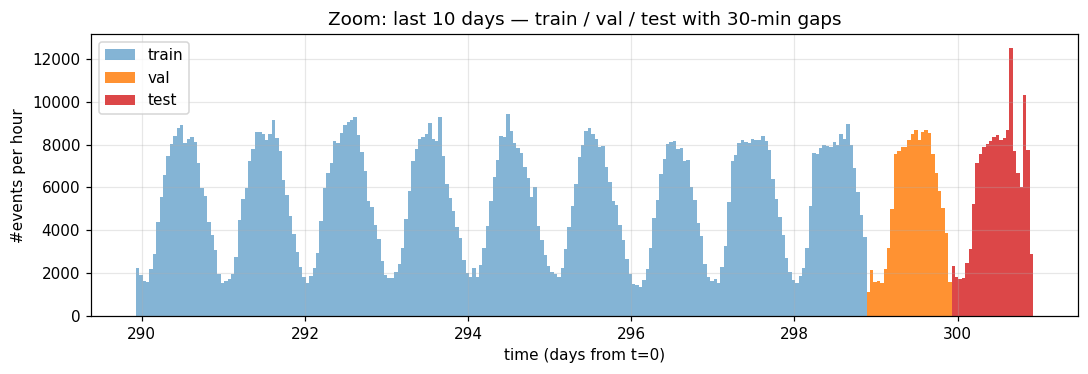

In [12]:
# Zoom: last 10 days, finer bins (1 hour)
BIN_H = 3600
lo = TEST_TIMESTAMP - 10 * 86_400
edges_h = np.arange(lo, ts_max + BIN_H, BIN_H)
centers_h = (edges_h[:-1] + edges_h[1:]) / 2 / 86_400
h_tr, _  = np.histogram(train.loc[train['timestamp'] >= lo, 'timestamp'], bins=edges_h)
h_va, _  = np.histogram(val['timestamp'],  bins=edges_h)
h_te, _  = np.histogram(test['timestamp'], bins=edges_h)

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.bar(centers_h, h_tr, width=BIN_H/86_400, alpha=0.55, label='train')
ax.bar(centers_h, h_va, width=BIN_H/86_400, alpha=0.85, label='val',  color='tab:orange')
ax.bar(centers_h, h_te, width=BIN_H/86_400, alpha=0.85, label='test', color='tab:red')
ax.set_xlabel('time (days from t=0)')
ax.set_ylabel('#events per hour')
ax.set_title('Zoom: last 10 days — train / val / test with 30-min gaps')
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / 'gts_timeline_zoom.png', bbox_inches='tight')
plt.show()

## 5. Чекпоинт Step E

- ✅ Loader+split воспроизводят числа Step 0 / real-data validation Step C-D.
- ✅ 4 PNG-графика лежат в `docs/figures/`.
- ➡️ Следующий шаг — **Step F** (`src/scorer/gsasrec.py`).

In [13]:
for f in sorted(FIG_DIR.iterdir()):
    print(f'  {f.relative_to(PROJECT_ROOT)}  ({f.stat().st_size/1024:.0f} KB)')

  docs/figures/gts_timeline.png  (80 KB)
  docs/figures/gts_timeline_zoom.png  (57 KB)
  docs/figures/history_length_hist.png  (63 KB)
  docs/figures/item_popularity_zipf.png  (79 KB)
